In [1]:
import os, glob, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.lib.stride_tricks import sliding_window_view
from scipy import stats as sp_stats

warnings.filterwarnings("ignore")
os.makedirs("figures_raw", exist_ok=True)
print("Ready")

Ready


In [2]:
# ── Normalization helpers ──
def winsorize_xs(s, k=3):
    med = s.median()
    mad = (s - med).abs().median() * 1.4826
    return s.clip(med - k * mad, med + k * mad)

def zscore_xs(s):
    sigma = s.std()
    return (s - s.mean()) / sigma if (sigma > 1e-6 and not np.isnan(sigma)) else s * 0.0

def rank_xs(s):
    return s.rank(pct=True)

def ts_standardize(s, window=20):
    mp = max(5, window // 2)
    rm = s.rolling(window, min_periods=mp).mean()
    rs = s.rolling(window, min_periods=mp).std().replace(0, np.nan)
    return (s - rm) / rs

def clip_mad_xs(s, k=5):
    med = s.median()
    mad = (s - med).abs().median() * 1.4826
    return s.clip(med - k * mad, med + k * mad)

def safe_rolling(s, boundary, window, min_periods, func="mean"):
    s2 = s.copy()
    s2.loc[boundary] = np.nan
    r = s2.rolling(window, min_periods=min_periods)
    return getattr(r, func)() if func != "sum" else r.sum()
print("Helpers defined")

Helpers defined


In [3]:
# %% Load Data
t0 = time.time()

files = sorted(glob.glob(os.path.join("intraday/", "*.csv")))
intra_raw = pd.concat(
    (pd.read_csv(f, dtype={"Id": "category", "Date": np.int32, "Time": str,
                           "CumReturnResid": np.float32, "CumReturnRaw": np.float32,
                           "CumVolume": np.float64})
     for f in files), ignore_index=True
)
intra_raw["Date"] = pd.to_datetime(intra_raw["Date"], format="%Y%m%d")
intra_raw["Time_str"] = intra_raw["Time"].astype(str).str.strip()
intra_raw["Time_td"] = pd.to_timedelta(intra_raw["Time_str"])
intra_raw["Hour"] = intra_raw["Time_td"].dt.total_seconds() / 3600.0
intra_raw = intra_raw.sort_values(["Id", "Date", "Time_td"]).reset_index(drop=True)

files = sorted(glob.glob(os.path.join("daily/", "*.csv")))
daily_raw = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
daily_raw.rename(columns={"ID": "Id"}, inplace=True)
daily_raw["Date"] = pd.to_datetime(daily_raw["Date"], format="%Y%m%d")
daily_raw = daily_raw.sort_values(["Date", "Id"]).reset_index(drop=True)
daily_raw["AdjClose"]  = daily_raw["Close"]  * daily_raw["PxAdjFactor"]
daily_raw["AdjOpen"]   = daily_raw["Open"]   * daily_raw["PxAdjFactor"]
daily_raw["AdjHigh"]   = daily_raw["High"]   * daily_raw["PxAdjFactor"]
daily_raw["AdjLow"]    = daily_raw["Low"]    * daily_raw["PxAdjFactor"]
daily_raw["AdjVolume"] = daily_raw["Volume"] / daily_raw["SharesAdjFactor"]
print(f"Loaded in {time.time()-t0:.1f}s — intra: {len(intra_raw):,}, daily: {len(daily_raw):,}")

Loaded in 97.9s — intra: 16,354,000, daily: 629,000


## Intraday Features (I1–I10)

In [4]:
t0 = time.time()
W = 10
lam = 0.1

intra = intra_raw.copy().sort_values(["Id", "Date", "Time_td"]).reset_index(drop=True)
n_intra = len(intra)

# ── Diffs at group boundaries ──
print("  Diffs & boundaries...")
boundary = (intra["Id"] != intra["Id"].shift(1)) | (intra["Date"] != intra["Date"].shift(1))

for src, dst in [("CumReturnResid", "dCumRetResid"),
                 ("CumReturnRaw",   "dCumRetRaw"),
                 ("CumVolume",      "dCumVolume")]:
    intra[dst] = intra[src].diff()
    intra.loc[boundary, dst] = np.nan

intra["FactorComp"]  = intra["CumReturnRaw"] - intra["CumReturnResid"]
intra["dFactorComp"] = intra["FactorComp"].diff()
intra.loc[boundary, "dFactorComp"] = np.nan
intra["d2CumRetResid"] = intra["dCumRetResid"].diff()
intra["d2CumVolume"]   = intra["dCumVolume"].diff()
intra.loc[boundary, "d2CumRetResid"] = np.nan
intra.loc[boundary, "d2CumVolume"]   = np.nan

# ── Reference snapshots ──
print("  Reference snapshots...")
gsd = intra.groupby(["Id", "Date"])
intra = intra.merge(gsd["CumReturnResid"].first().rename("CumRetResid_0945"), on=["Id", "Date"], how="left")
ref_1000 = intra.loc[intra["Time_td"] == pd.Timedelta(hours=10), ["Id", "Date", "CumReturnResid"]].rename(columns={"CumReturnResid": "CumRetResid_1000"})
intra = intra.merge(ref_1000, on=["Id", "Date"], how="left")

# ── I1: Overnight Residual Return ──
print("  I1–I3...")
intra["I1_OvernightResidReturn"] = intra["CumRetResid_0945"]

# ── I2: Overnight-vs-Intraday Disconnect ──
intra["I2_OvernightIntradayDisconnect"] = intra["CumRetResid_0945"] - (intra["CumReturnResid"] - intra["CumRetResid_0945"])

# ── I3: Anchor-Decayed Residual Displacement ──
decay = np.exp(-lam * (intra["Hour"].values - 10.0))
displacement = intra["CumReturnResid"].values - intra["CumRetResid_1000"].values * decay
sigma_W = safe_rolling(intra["dCumRetResid"], boundary, W, 3, "std").replace(0, np.nan)
intra["I3_AnchorDecayedDisplacement"] = displacement / sigma_W.values

# ── I4: VWAR ──
print("  I4 (VWAR)...")
wr = intra["dCumRetResid"] * intra["dCumVolume"]
intra["I4_VWAR"] = safe_rolling(wr, boundary, W, 3, "sum") / safe_rolling(intra["dCumVolume"], boundary, W, 3, "sum").replace(0, np.nan)

# ── I5: Kyle's Lambda ──
print("  I5 (Kyle's Lambda)...")
intra["SignedVol"] = intra["dCumVolume"] * np.sign(intra["dCumRetRaw"])
xy = intra["dCumRetResid"] * intra["SignedVol"]
cov = safe_rolling(xy, boundary, W, 3, "mean") - safe_rolling(intra["dCumRetResid"], boundary, W, 3, "mean") * safe_rolling(intra["SignedVol"], boundary, W, 3, "mean")
var_y = safe_rolling(intra["SignedVol"], boundary, W, 3, "var").replace(0, np.nan)
intra["I5_KyleLambda"] = cov / var_y

# ── I6: Ghost Liquidity ──
print("  I6...")
intra["I6_GhostLiquidity"] = np.log1p(intra["dCumRetResid"].abs() / np.log1p(intra["dCumVolume"].clip(lower=0)))

# ── I7: Abnormal Volume (13k groups) ──
print("  I7 (Abnormal Volume)...")
intra = intra.sort_values(["Id", "Time_td", "Date"]).reset_index(drop=True)
avg_vol = intra.groupby(["Id", "Time_td"])["CumVolume"].rolling(20, min_periods=5).mean()
avg_vol = avg_vol.reset_index(level=[0, 1], drop=True).sort_index().replace(0, np.nan)
intra["I7_AbnormalVolume"] = np.log(intra["CumVolume"] / avg_vol)
intra = intra.sort_values(["Id", "Date", "Time_td"]).reset_index(drop=True)

# ── I8: Shadow Vol Divergence ──
print("  I8 (Shadow Vol Divergence)...")
k = 10
d2v_x_d2r = intra["d2CumVolume"] * intra["d2CumRetResid"]
r_xy8 = safe_rolling(d2v_x_d2r, boundary, k, 4, "mean")
r_d2v = safe_rolling(intra["d2CumVolume"], boundary, k, 4, "mean")
r_d2r = safe_rolling(intra["d2CumRetResid"], boundary, k, 4, "mean")
cov8 = r_xy8 - r_d2v * r_d2r
s_d2v = safe_rolling(intra["d2CumVolume"], boundary, k, 4, "std")
s_d2r = safe_rolling(intra["d2CumRetResid"], boundary, k, 4, "std")
intra["I8_ShadowVolDivergence"] = -(cov8 / (s_d2v * s_d2r).replace(0, np.nan))

# ── I9: Max Drawdown (500 stock groups) ──
print("  I9 (Max Drawdown)...")
result_mdd = np.full(n_intra, np.nan)
for stock_id, grp in intra.groupby("Id"):
    idx = grp.index.values
    vals = grp["CumReturnResid"].values.astype(np.float64)
    m = len(vals)
    if m >= W:
        wins = sliding_window_view(vals, W)
        cm = np.maximum.accumulate(wins, axis=1)
        dd = np.max(cm - wins, axis=1)
        local = np.full(m, np.nan)
        local[W - 1:] = dd
        result_mdd[idx] = local
intra["I9_MaxDrawdown"] = result_mdd

# ── I10: Divergence Velocity ──
print("  I10...")
intra["I10_DivergenceVelocity"] = safe_rolling(intra["dFactorComp"], boundary, W, 3, "std")

print(f"Intraday features done in {time.time()-t0:.1f}s")

  Diffs & boundaries...
  Reference snapshots...
  I1–I3...
  I4 (VWAR)...
  I5 (Kyle's Lambda)...
  I6...
  I7 (Abnormal Volume)...
  I8 (Shadow Vol Divergence)...
  I9 (Max Drawdown)...
  I10...
Intraday features done in 33.9s


## I11 Permutation Entropy

In [5]:
# ── I11: Permutation Entropy (per-stock cumsum) ──
print("  I11 (Permutation Entropy)...")
pat_window = 12 - 3 + 1  # w - m + 1 = 10
result_pe = np.full(n_intra, np.nan)

for stock_id, grp in intra.groupby("Id"):
    vals = grp["dCumRetResid"].values.astype(np.float64)
    n = len(vals)
    if n < 12:
        continue
    v0, v1, v2 = vals[:-2], vals[1:-1], vals[2:]
    pid = ((v0 < v1).astype(np.int8) * 4 + (v0 < v2).astype(np.int8) * 2 + (v1 < v2).astype(np.int8))
    pv = np.isfinite(v0) & np.isfinite(v1) & np.isfinite(v2)
    np_ = len(pid)
    if np_ < pat_window:
        continue
    ind = np.zeros((np_, 8), dtype=np.float64)
    for p in range(8):
        ind[:, p] = ((pid == p) & pv)
    cs = np.vstack([np.zeros((1, 8)), np.cumsum(ind, axis=0)])
    counts = cs[pat_window:] - cs[:-pat_window]
    total = counts.sum(axis=1, keepdims=True)
    total[total == 0] = np.nan
    probs = counts / total
    with np.errstate(divide='ignore', invalid='ignore'):
        log_p = np.where(probs > 0, np.log2(probs), 0.0)
    entropy = -np.sum(probs * log_p, axis=1)
    offset = pat_window - 1 + 2  # 11
    idx = grp.index.values
    end = min(offset + len(entropy), n)
    result_pe[idx[offset:end]] = entropy[:end - offset]

intra["I11_PermutationEntropy"] = result_pe

  I11 (Permutation Entropy)...


## Aggregate Intraday at 15:30 + A1–A3

In [6]:
# %% Cell 4 — Aggregate Intraday at 15:30
t0 = time.time()

FCOLS = ["I1_OvernightResidReturn", "I2_OvernightIntradayDisconnect",
         "I3_AnchorDecayedDisplacement", "I4_VWAR", "I5_KyleLambda",
         "I6_GhostLiquidity", "I7_AbnormalVolume", "I8_ShadowVolDivergence",
         "I9_MaxDrawdown", "I10_DivergenceVelocity", "I11_PermutationEntropy"]

target_time = pd.Timedelta(hours=15, minutes=30)
snap_1530 = intra[intra["Time_td"] == target_time].copy().reset_index(drop=True)
keep = ["Id", "Date"] + [c for c in FCOLS if c in snap_1530.columns]
intra_agg = snap_1530[keep].copy()

# A1: Realized range (up to 15:30)
intra_up_to = intra[intra["Time_td"] <= target_time]
g = intra_up_to.groupby(["Id", "Date"])["CumReturnRaw"]
intra_agg = intra_agg.merge((g.max() - g.min()).rename("A1_RealizedRange").reset_index(), on=["Id", "Date"], how="left")

# A2: Morning vs afternoon
mid = pd.Timedelta(hours=12)
intra_s = intra_up_to.sort_values(["Id", "Date", "Time_td"])
morning = intra_s[intra_s["Time_td"] <= mid]
mf = morning.groupby(["Id", "Date"])["CumReturnResid"].first()
ml = morning.groupby(["Id", "Date"])["CumReturnResid"].last()
al = intra_s.groupby(["Id", "Date"])["CumReturnResid"].last()
intra_agg = intra_agg.merge((ml - mf).rename("A2_MorningReturn").reset_index(), on=["Id", "Date"], how="left")
intra_agg = intra_agg.merge((al - ml).rename("A2_AfternoonReturn").reset_index(), on=["Id", "Date"], how="left")
intra_agg["A2_MorningAfternoonDiff"] = intra_agg["A2_MorningReturn"] - intra_agg["A2_AfternoonReturn"]

# A3: Volume concentration
tv = intra_s.groupby(["Id", "Date"])["CumVolume"].last().rename("_tv")
fh = intra_s[intra_s["Time_td"] <= pd.Timedelta(hours=10, minutes=45)]
vf = fh.groupby(["Id", "Date"])["CumVolume"].last().rename("_vf")
lh = intra_s[intra_s["Time_td"] >= pd.Timedelta(hours=15)]
vl = lh.groupby(["Id", "Date"])["CumVolume"].first().rename("_vl")
vc = pd.concat([tv, vf, vl], axis=1).reset_index()
tvn = vc["_tv"].replace(0, np.nan)
vc["A3_VolConcFirst1h"] = vc["_vf"] / tvn
vc["A3_VolConcLast1h"] = (vc["_tv"] - vc["_vl"]) / tvn
intra_agg = intra_agg.merge(vc[["Id", "Date", "A3_VolConcFirst1h", "A3_VolConcLast1h"]], on=["Id", "Date"], how="left")

print(f"Aggregated at 15:30 in {time.time()-t0:.1f}s — {len(intra_agg):,} rows")

Aggregated at 15:30 in 17.3s — 629,000 rows


## Daily Features (D1–D4)

In [7]:
# %% Cell 6 — Daily Features (D1–D4)
t0 = time.time()
daily = daily_raw.copy().sort_values(["Id", "Date"]).reset_index(drop=True)
gs = daily.groupby("Id")

daily["LogReturn"] = gs["AdjClose"].transform(lambda s: np.log(s / s.shift(1)))
daily["SimpleReturn"] = gs["AdjClose"].transform(lambda s: s / s.shift(1) - 1)

# D1: Trailing Realized Volatility Ratio
rv = gs["LogReturn"].transform(lambda s: s.rolling(21, min_periods=10).std()) * np.sqrt(252)
ev = daily["EST_VOL"].replace(0, np.nan)
daily["D1_VolRatio"] = np.log((rv / ev).clip(lower=1e-6))
daily["D1_VolRatio"] = gs["D1_VolRatio"].transform(lambda s: ts_standardize(s, 63))

# D2: 5-Day Return Reversal
daily["D2_raw"] = gs["AdjClose"].transform(lambda s: s / s.shift(5) - 1)
daily["D2_Ret5d"] = daily["D2_raw"] / gs["D2_raw"].transform(lambda s: s.rolling(63, min_periods=20).std()).replace(0, np.nan)

# D3: Volume Trend
mv5  = gs["AdjVolume"].transform(lambda s: s.rolling(5, min_periods=3).median())
mv63 = gs["AdjVolume"].transform(lambda s: s.rolling(63, min_periods=20).median()).replace(0, np.nan)
daily["D3_VolTrend"] = np.log(mv5 / mv63)
daily["D3_VolTrend"] = gs["D3_VolTrend"].transform(lambda s: ts_standardize(s, 63))

# D4: Range / Overnight Gap
pc = gs["AdjClose"].shift(1)
daily["D4_RangeGap"] = np.log1p((daily["AdjHigh"] - daily["AdjLow"]) / ((daily["AdjOpen"] - pc).abs() + 1e-8))
daily["D4_RangeGap"] = gs["D4_RangeGap"].transform(lambda s: ts_standardize(s, 21))

d_cols = ["D1_VolRatio", "D2_Ret5d", "D3_VolTrend", "D4_RangeGap"]
for col in d_cols:
    daily[col] = daily.groupby("Id")[col].shift(1)

daily_feat = daily[["Id", "Date"] + d_cols + ["FREE_FLOAT_PERCENTAGE", "EST_VOL", "MDV_63"]].copy()

print(f"Daily features done in {time.time()-t0:.1f}s")


Daily features done in 4.9s


## Cross-Sectional Features (C1–C3)

In [8]:
intra_1530 = intra[intra["Time_td"] <= pd.Timedelta(hours=15, minutes=30)].copy()
t0 = time.time()

# C1: Residual Momentum Rank
# intra_1530 is ALREADY sorted by (Id, Date, Time_td) — no need to re-sort
gid_c = intra_1530.groupby(["Id", "Date"])["CumReturnResid"]
rr = (gid_c.last() - gid_c.first()).rename("IntradayResidReturn").reset_index()
rr["C1_ResidMomRank"] = rr.groupby("Date")["IntradayResidReturn"].rank(pct=True)

# C2: Vortex Score
print("  C2 (Vortex Score)...")
n_snaps = 5
valid = intra_1530.loc[intra_1530["dCumRetResid"].notna(), ["Id", "Date", "dCumRetResid"]]
last5 = valid.groupby(["Id", "Date"]).tail(n_snaps)

# Single groupby to collect sorted arrays (NOT nested)
pairs = last5.groupby(["Date", "Id"])["dCumRetResid"].apply(lambda x: np.sort(x.values))
pairs = pairs[pairs.apply(len) >= 3].reset_index()
pairs.columns = ["Date", "Id", "vals"]

# Build date_stocks dict — 1258 iterations, not 629k
date_stocks = {}
for date, grp in pairs.groupby("Date"):
    date_stocks[date] = list(zip(grp["Id"], grp["vals"]))

# KS computation
cdf_cache = {}
for kk in range(3, n_snaps + 1):
    cdf_cache[kk] = (np.arange(1, kk + 1) / kk, np.arange(0, kk) / kk)

result_dates, result_ids, result_ks = [], [], []
for date, stock_list in date_stocks.items():
    pool = np.sort(np.concatenate([sv for _, sv in stock_list]))
    inv_n = 1.0 / len(pool)
    for sid, inc_sorted in stock_list:
        kk = len(inc_sorted)
        pool_cdf = np.searchsorted(pool, inc_sorted, side='right') * inv_n
        s_cdf, s_cdf_bef = cdf_cache[kk]
        ks = max(np.max(np.abs(s_cdf - pool_cdf)), np.max(np.abs(s_cdf_bef - pool_cdf)))
        result_dates.append(date); result_ids.append(sid); result_ks.append(ks)

vdf = pd.DataFrame({"Date": result_dates, "Id": result_ids, "C2_VortexScore": result_ks})

# C3: Liquidity Score
eps = 1e-4
dc = daily_raw[["Date", "Id", "MDV_63", "FREE_FLOAT_PERCENTAGE"]].copy()
dc["C3_LiqScore"] = np.log(dc["MDV_63"] / (dc["FREE_FLOAT_PERCENTAGE"] / 100 + eps))
dc = dc.sort_values(["Id", "Date"])
dc["C3_LiqScore"] = dc.groupby("Id")["C3_LiqScore"].transform(lambda s: ts_standardize(s, 63))

cs_feat = rr[["Id", "Date", "C1_ResidMomRank"]].copy()
cs_feat = cs_feat.merge(vdf, on=["Id", "Date"], how="left")
cs_feat = cs_feat.merge(dc[["Id", "Date", "C3_LiqScore"]], on=["Id", "Date"], how="left")

print(f"Cross-sectional features done in {time.time()-t0:.1f}s")

  C2 (Vortex Score)...
Cross-sectional features done in 25.3s


## Time-Series Normalization (intraday features)

In [9]:
# ── Time-series normalization for intraday features ──
ts_norm_cols = ["I4_VWAR", "I5_KyleLambda", "I6_GhostLiquidity",
                "I9_MaxDrawdown", "I10_DivergenceVelocity",
                "A1_RealizedRange"]

for col in ts_norm_cols:
    if col in intra_agg.columns:
        intra_agg[col] = intra_agg.groupby("Id")[col].transform(
            lambda s: ts_standardize(s, 20))

print(f"TS-normalized {len(ts_norm_cols)} intraday features (20-day rolling)")

TS-normalized 6 intraday features (20-day rolling)


## Extended Features (E1–E10)

In [11]:
# %% Cell 10 — Extended Features (E1–E10)
t0 = time.time()
print("Computing extended features (E1–E10)...")

def gid(col): return daily.groupby("Id")[col]

# E1: Rolling Beta
mkt_ret = daily.groupby("Date")["LogReturn"].mean().rename("_mkt")
daily = daily.merge(mkt_ret, on="Date", how="left")
daily["_sxm"] = daily["LogReturn"] * daily["_mkt"]
_rxy = gid("_sxm").transform(lambda s: s.rolling(63, min_periods=21).mean())
_rx = gid("LogReturn").transform(lambda s: s.rolling(63, min_periods=21).mean())

# Market rolling stats at date level (avoids cross-Id contamination)
_mkt_by_date = daily.groupby("Date")["_mkt"].first()
_mkt_rm = _mkt_by_date.rolling(63, min_periods=21).mean().rename("_mkt_rm")
_mkt_rv = _mkt_by_date.rolling(63, min_periods=21).var().replace(0, np.nan).rename("_mkt_rv")
daily = daily.merge(_mkt_rm, on="Date", how="left")
daily = daily.merge(_mkt_rv, on="Date", how="left")
daily["E1_Beta63d"] = (_rxy - _rx * daily["_mkt_rm"]) / daily["_mkt_rv"]
daily.drop(columns=["_mkt_rm", "_mkt_rv"], inplace=True)

# E2: Beta Deviation
daily["E2_BetaDeviation"] = daily["E1_Beta63d"] - gid("E1_Beta63d").transform(lambda s: s.rolling(252, min_periods=63).mean())
daily.drop(columns=["_sxm", "_mkt"], inplace=True)

# E3: Corwin-Schultz Spread
h, l = np.log(daily["AdjHigh"]), np.log(daily["AdjLow"])
hl = h - l
hl_prev = np.log(gid("AdjHigh").shift(1)) - np.log(gid("AdjLow").shift(1))
h2 = pd.concat([h, np.log(gid("AdjHigh").shift(1))], axis=1).max(axis=1)
l2 = pd.concat([l, np.log(gid("AdjLow").shift(1))], axis=1).min(axis=1)
daily["_hl2_sum"] = hl**2 + hl_prev**2
daily["_h2l2_sq"] = (h2 - l2)**2
beta_cs = daily.groupby("Id")["_hl2_sum"].transform(lambda s: s.rolling(21, min_periods=10).mean())
gamma_cs = daily.groupby("Id")["_h2l2_sq"].transform(lambda s: s.rolling(21, min_periods=10).mean())
daily.drop(columns=["_hl2_sum", "_h2l2_sq"], inplace=True)
alpha_cs = ((np.sqrt(2*beta_cs) - np.sqrt(beta_cs)) / (3 - 2*np.sqrt(2)) - np.sqrt(gamma_cs / (3 - 2*np.sqrt(2)))).clip(lower=0)
daily["E3_CorwinSchultzSpread"] = np.log1p(2 * (np.exp(alpha_cs) - 1) / (1 + np.exp(alpha_cs)))

# E4/E5: MAX5/MIN5
'''
daily["E4_MAX5"] = gid("SimpleReturn").transform(lambda s: s.rolling(21, min_periods=10).apply(lambda w: np.sort(w)[-5:].mean() if len(w)>=5 else np.nan, raw=True))
daily["E5_MIN5"] = gid("SimpleReturn").transform(lambda s: s.rolling(21, min_periods=10).apply(lambda w: np.sort(w)[:5].mean() if len(w)>=5 else np.nan, raw=True))
'''
daily["E4_MAX5"] = gid("SimpleReturn").transform(lambda s: s.rolling(21, min_periods=10).apply(
    lambda w: np.partition(w, -5)[-5:].mean() if len(w) >= 5 else np.nan, raw=True))
daily["E5_MIN5"] = gid("SimpleReturn").transform(lambda s: s.rolling(21, min_periods=10).apply(
    lambda w: np.partition(w, 5)[:5].mean() if len(w) >= 5 else np.nan, raw=True))


# E8: MACD
ema12 = gid("AdjClose").transform(lambda s: s.ewm(span=12, min_periods=8).mean())
ema26 = gid("AdjClose").transform(lambda s: s.ewm(span=26, min_periods=18).mean())
daily["E8_MACD"] = (ema12 - ema26) / daily["AdjClose"].replace(0, np.nan)

# E9: Bollinger Band Position
sma20 = gid("AdjClose").transform(lambda s: s.rolling(20, min_periods=10).mean())
std20 = gid("AdjClose").transform(lambda s: s.rolling(20, min_periods=10).std()).replace(0, np.nan)
daily["E9_BollingerPos"] = (daily["AdjClose"] - sma20) / (2 * std20)

# E10: Volume Volatility
vmean = gid("AdjVolume").transform(lambda s: s.rolling(21, min_periods=10).mean())
vstd  = gid("AdjVolume").transform(lambda s: s.rolling(21, min_periods=10).std())
daily["E10_VolVolatility"] = vstd / vmean.replace(0, np.nan)

# TS normalization
for col, w in {"E1_Beta63d": 252, "E3_CorwinSchultzSpread": 63, "E4_MAX5": 63, "E5_MIN5": 63, "E10_VolVolatility": 63}.items():
    mp = max(5, w // 2)
    rm = gid(col).transform(lambda s: s.rolling(w, min_periods=mp).mean())
    rs = gid(col).transform(lambda s: s.rolling(w, min_periods=mp).std()).replace(0, np.nan)
    daily[col] = (daily[col] - rm) / rs

# Merge + XS normalize (skip calendar features entirely)
E_COLS = ["E1_Beta63d", "E2_BetaDeviation", "E3_CorwinSchultzSpread",
          "E4_MAX5", "E5_MIN5", "E8_MACD", "E9_BollingerPos", "E10_VolVolatility"]
E_COLS = [c for c in E_COLS if c in daily.columns]
for col in E_COLS:
    daily[col] = daily.groupby("Id")[col].shift(1)


print(f"Extended features done in {time.time()-t0:.1f}s")

Computing extended features (E1–E10)...
Extended features done in 17.1s


# Raw Feature Analysis (before any clipping or XS normalization)

In [12]:
# ════════════════════════════════════════════
# MERGE RAW FEATURES (NO CLIPPING, NO XS NORMALIZATION)
# ════════════════════════════════════════════
E_COLS = ["E1_Beta63d", "E2_BetaDeviation", "E3_CorwinSchultzSpread",
          "E4_MAX5", "E5_MIN5", "E8_MACD", "E9_BollingerPos", "E10_VolVolatility"]

df_raw = daily_feat.merge(intra_agg, on=["Id", "Date"], how="left")
df_raw = df_raw.merge(cs_feat, on=["Id", "Date"], how="left")
df_raw = df_raw.merge(daily[["Id", "Date"] + E_COLS], on=["Id", "Date"], how="left")

# Drop warmup
all_dates = np.sort(df_raw["Date"].unique())
warmup_days = 260
cutoff_date = all_dates[warmup_days]
df_raw = df_raw[df_raw["Date"] >= cutoff_date].copy()

# Training period only
df_raw_train = df_raw[df_raw["Date"] < pd.Timestamp("2014-01-01")]

# Our 18 final features
FEAT_18 = ["D3_VolTrend", "D4_RangeGap", "I2_OvernightIntradayDisconnect",
           "I4_VWAR", "I5_KyleLambda", "I6_GhostLiquidity", "I7_AbnormalVolume",
           "I8_ShadowVolDivergence", "I9_MaxDrawdown", "A1_RealizedRange",
           "A2_MorningReturn", "A2_AfternoonReturn", "A2_MorningAfternoonDiff",
           "A3_VolConcFirst1h", "A3_VolConcLast1h", "C1_ResidMomRank",
           "E2_BetaDeviation", "E9_BollingerPos"]
ALL_FEAT = [c for c in FEAT_18 if c in df_raw_train.columns]

print(f"Raw features merged: {len(df_raw_train):,} rows, {len(ALL_FEAT)} features")
print(f"Date range: {df_raw_train['Date'].min().date()} to {df_raw_train['Date'].max().date()}")

Raw features merged: 373,000 rows, 18 features
Date range: 2011-01-13 to 2013-12-31


## 1. Raw Distribution Stats

In [13]:
print(f"{'Feature':<35} {'Mean':>8} {'Std':>8} {'Skew':>8} {'Kurt':>8} {'P1':>8} {'P99':>8} {'%>3MAD':>8}")
print("=" * 100)

mad_analysis = {}
for col in ALL_FEAT:
    s = df_raw_train.groupby("Date")[col]

    def pct_beyond_3mad(x):
        med = x.median()
        mad = (x - med).abs().median() * 1.4826
        if mad == 0:
            return 0.0
        beyond = ((x < med - 3 * mad) | (x > med + 3 * mad)).mean() * 100
        return beyond

    pct_beyond = s.apply(pct_beyond_3mad).mean()

    raw = df_raw_train[col].dropna()
    print(f"{col:<35} {raw.mean():>8.3f} {raw.std():>8.3f} {raw.skew():>8.2f} "
          f"{raw.kurtosis():>8.2f} {raw.quantile(0.01):>8.3f} {raw.quantile(0.99):>8.3f} "
          f"{pct_beyond:>7.2f}%")
    mad_analysis[col] = {"pct_beyond_3mad": pct_beyond, "kurtosis": raw.kurtosis()}

Feature                                 Mean      Std     Skew     Kurt       P1      P99   %>3MAD
D3_VolTrend                            0.021    1.119     0.40     0.61   -2.362    3.043    1.11%
D4_RangeGap                            0.001    0.977     1.92     4.78   -1.463    4.211    9.63%
I2_OvernightIntradayDisconnect         0.000    0.015     5.73   967.00   -0.036    0.037    4.03%
I4_VWAR                               -0.000    0.979     0.10     0.86   -2.415    2.557    1.38%
I5_KyleLambda                          0.002    0.990     0.32     0.10   -2.087    2.530    0.48%
I6_GhostLiquidity                        inf      nan      nan      nan   -1.393    2.971    2.62%
I7_AbnormalVolume                       -inf      nan      nan      nan   -0.985    1.056    1.98%
I8_ShadowVolDivergence                -0.008    0.380     0.01    -0.73   -0.776    0.771    0.46%
I9_MaxDrawdown                        -0.003    0.985     1.05     1.12   -1.571    3.043    3.05%
A1_Realize

## 2. Raw vs Winsorized Histograms

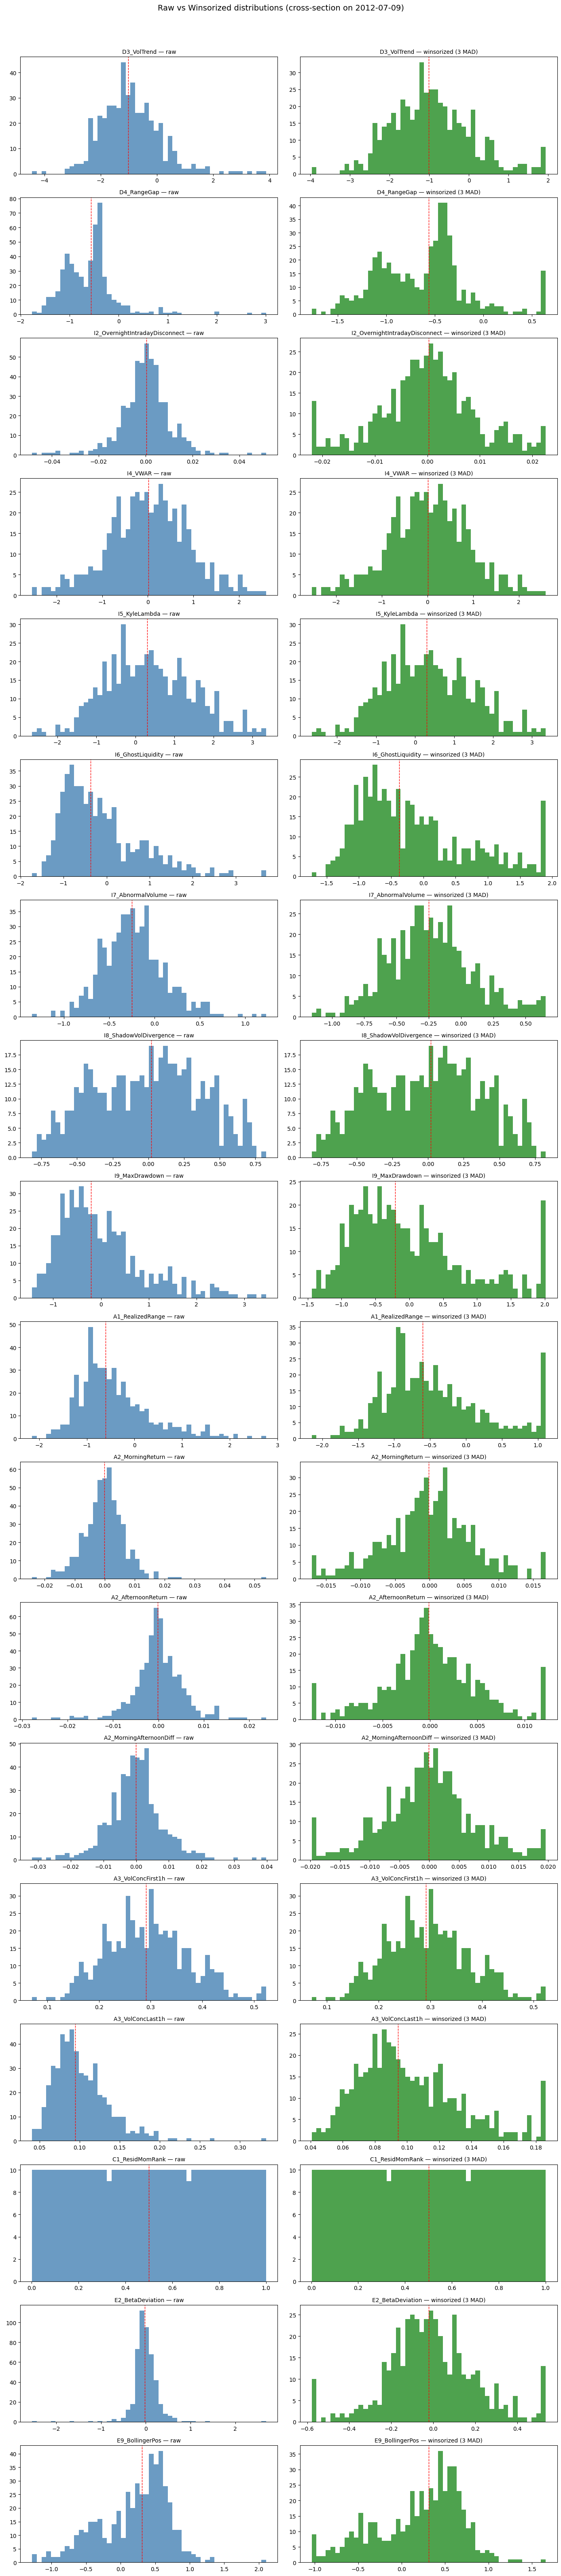

In [20]:
sample_date = df_raw_train["Date"].unique()[len(df_raw_train["Date"].unique()) // 2]
sample = df_raw_train[df_raw_train["Date"] == sample_date]

fig, axes = plt.subplots(len(ALL_FEAT), 2, figsize=(14, 3.5 * len(ALL_FEAT)))
for i, col in enumerate(ALL_FEAT):
    raw_vals = sample[col].dropna()

    axes[i, 0].hist(raw_vals, bins=50, color="steelblue", edgecolor="none", alpha=0.8)
    axes[i, 0].set_title(f"{col} — raw", fontsize=10)
    axes[i, 0].axvline(raw_vals.median(), color="red", linewidth=1, linestyle="--")

    clipped = winsorize_xs(raw_vals, k=3)
    axes[i, 1].hist(clipped, bins=50, color="forestgreen", edgecolor="none", alpha=0.8)
    axes[i, 1].set_title(f"{col} — winsorized (3 MAD)", fontsize=10)
    axes[i, 1].axvline(clipped.median(), color="red", linewidth=1, linestyle="--")

plt.suptitle(f"Raw vs Winsorized distributions (cross-section on {sample_date.date()})",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures_raw/raw_vs_winsorized.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. MAD Threshold Comparison

In [15]:
print(f"{'Feature':<35} {'%>2MAD':>8} {'%>3MAD':>8} {'%>4MAD':>8} {'%>5MAD':>8}")
print("=" * 75)

for col in ALL_FEAT:
    s = df_raw_train.groupby("Date")[col]
    pcts = {}
    for k in [2, 3, 4, 5]:
        def pct_beyond_k(x, k=k):
            med = x.median()
            mad = (x - med).abs().median() * 1.4826
            if mad == 0:
                return 0.0
            return ((x < med - k * mad) | (x > med + k * mad)).mean() * 100
        pcts[k] = s.apply(pct_beyond_k).mean()
    print(f"{col:<35} {pcts[2]:>7.2f}% {pcts[3]:>7.2f}% {pcts[4]:>7.2f}% {pcts[5]:>7.2f}%")

Feature                               %>2MAD   %>3MAD   %>4MAD   %>5MAD
D3_VolTrend                            5.95%    1.11%    0.25%    0.06%
D4_RangeGap                           17.28%    9.63%    6.10%    4.08%
I2_OvernightIntradayDisconnect        10.40%    4.03%    1.97%    1.14%
I4_VWAR                                7.49%    1.38%    0.22%    0.02%
I5_KyleLambda                          5.07%    0.48%    0.02%    0.00%
I6_GhostLiquidity                      8.56%    2.62%    0.56%    0.07%
I7_AbnormalVolume                      7.54%    1.98%    0.66%    0.24%
I8_ShadowVolDivergence                 0.76%    0.46%    0.46%    0.46%
I9_MaxDrawdown                         8.94%    3.05%    0.78%    0.14%
A1_RealizedRange                       7.51%    2.45%    0.82%    0.25%
A2_MorningReturn                       9.99%    3.56%    1.52%    0.74%
A2_AfternoonReturn                    10.34%    3.75%    1.61%    0.80%
A2_MorningAfternoonDiff               10.08%    3.60%    1.52%  

## 4. Individual Raw Feature Distributions (pooled)

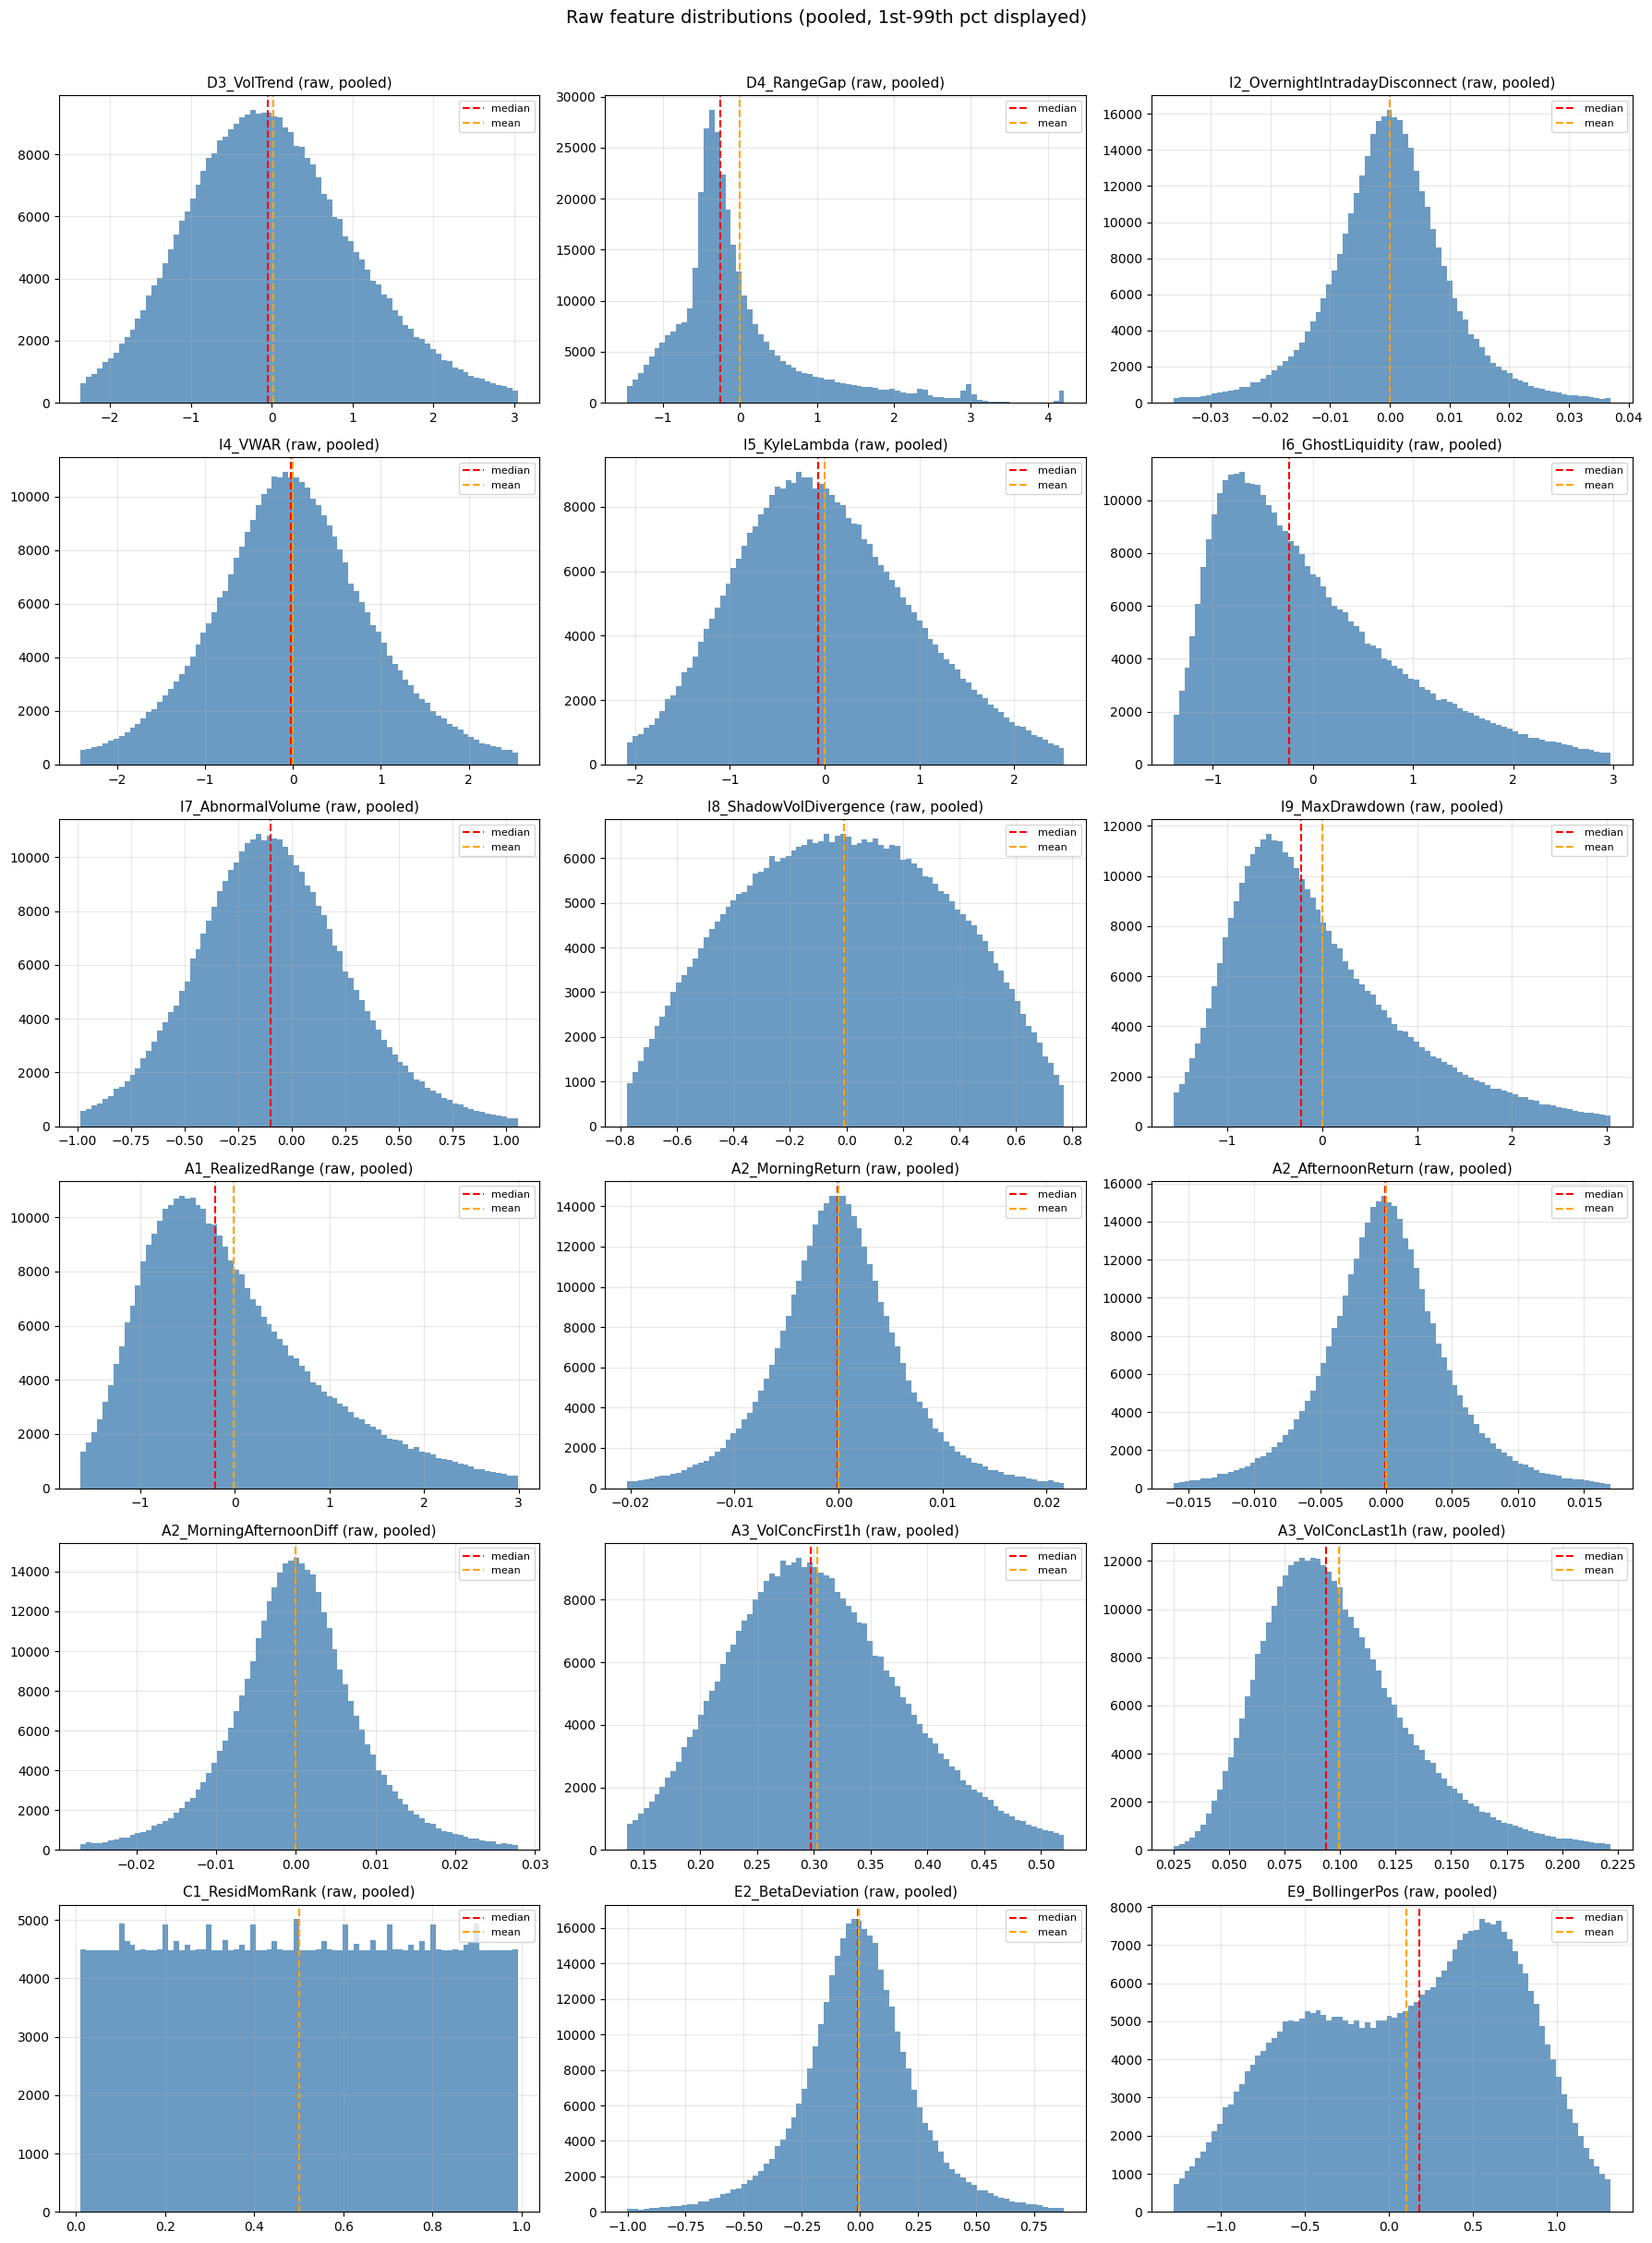

In [16]:
fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(ALL_FEAT):
    raw = df_raw_train[col].dropna()
    lo, hi = raw.quantile(0.01), raw.quantile(0.99)
    display = raw[(raw >= lo) & (raw <= hi)]

    axes[i].hist(display, bins=80, color="steelblue", edgecolor="none", alpha=0.8)
    axes[i].axvline(raw.median(), color="red", linewidth=1.5, linestyle="--", label="median")
    axes[i].axvline(raw.mean(), color="orange", linewidth=1.5, linestyle="--", label="mean")
    axes[i].set_title(f"{col} (raw, pooled)", fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

for j in range(len(ALL_FEAT), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Raw feature distributions (pooled, 1st-99th pct displayed)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures_raw/raw_distributions_pooled.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Skewness and Kurtosis

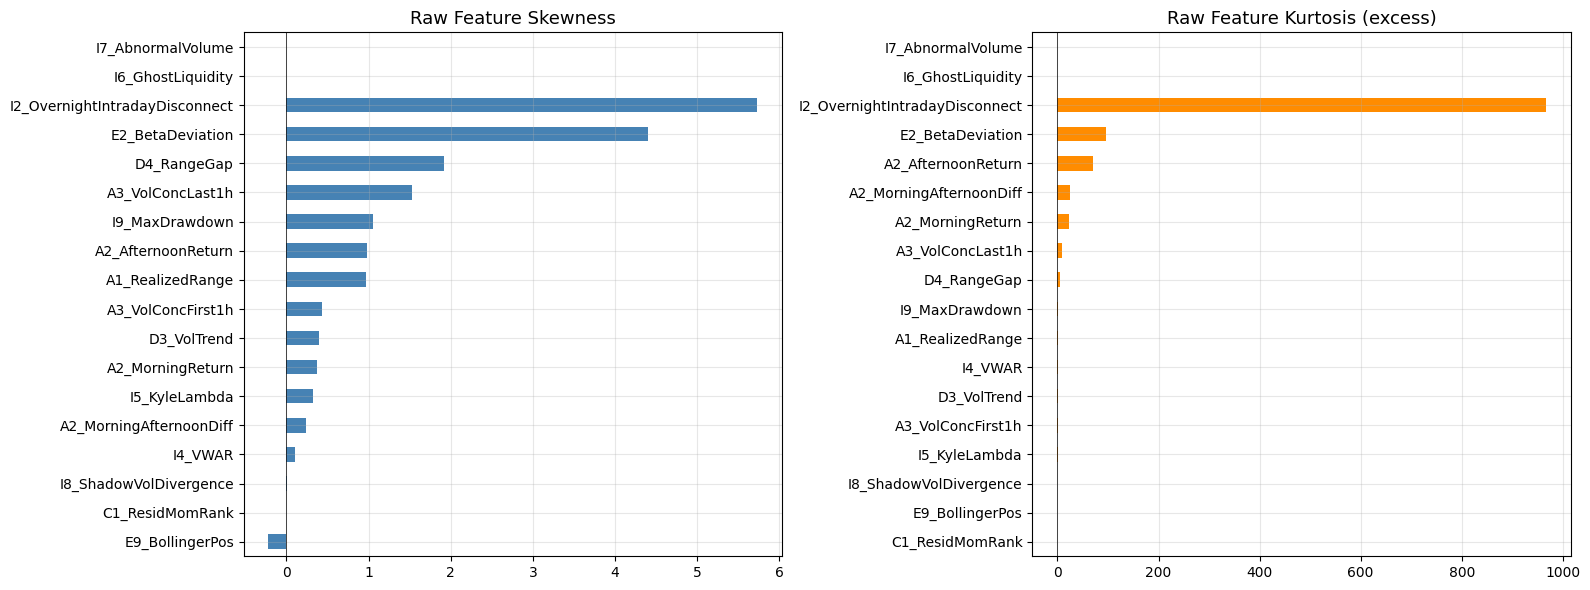

In [17]:
stats_df = pd.DataFrame({
    col: {"Skew": df_raw_train[col].dropna().skew(),
          "Kurtosis": df_raw_train[col].dropna().kurtosis()}
    for col in ALL_FEAT
}).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

stats_df["Skew"].sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Raw Feature Skewness", fontsize=13)
axes[0].axvline(0, color="black", linewidth=0.5)
axes[0].grid(True, alpha=0.3)

stats_df["Kurtosis"].sort_values().plot.barh(ax=axes[1], color="darkorange")
axes[1].set_title("Raw Feature Kurtosis (excess)", fontsize=13)
axes[1].axvline(0, color="black", linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figures_raw/skew_kurtosis.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. QQ Plots (raw features vs normal)

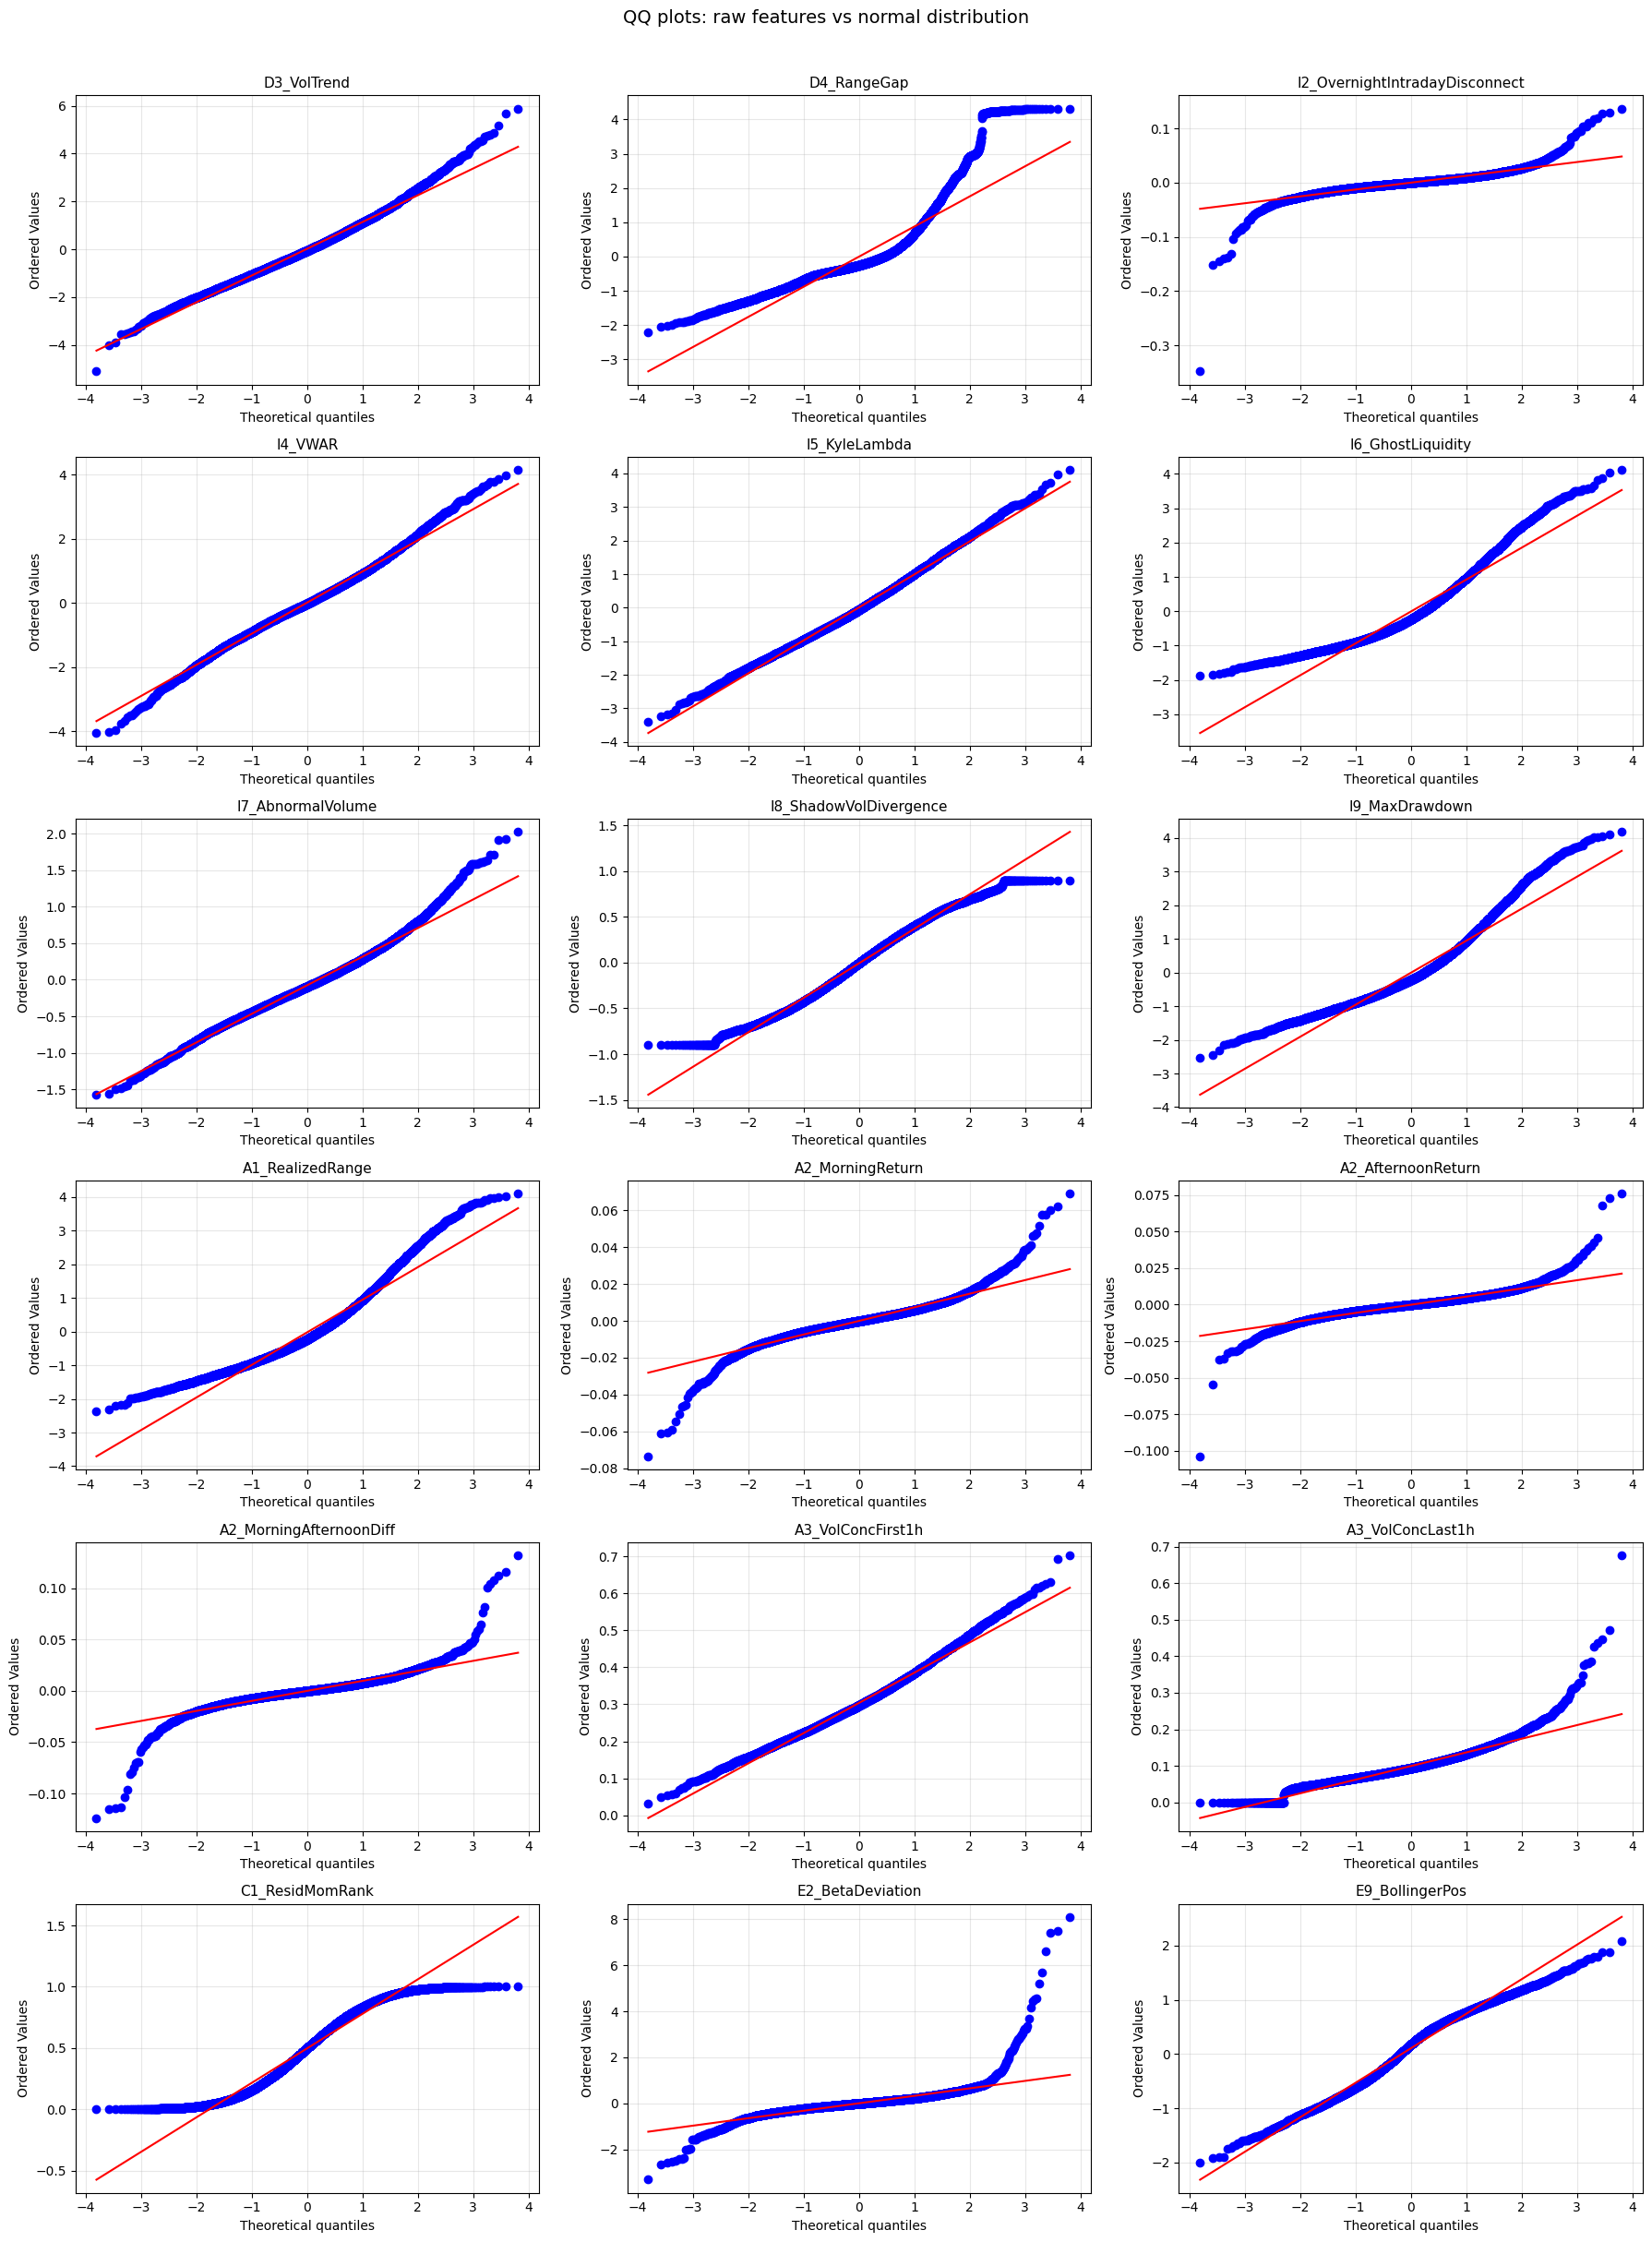

In [18]:
fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, col in enumerate(ALL_FEAT):
    raw = df_raw_train[col].dropna().values
    if len(raw) > 10000:
        raw = np.random.choice(raw, 10000, replace=False)
    sp_stats.probplot(raw, dist="norm", plot=axes[i])
    axes[i].set_title(f"{col}", fontsize=11)
    axes[i].grid(True, alpha=0.3)

for j in range(len(ALL_FEAT), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("QQ plots: raw features vs normal distribution", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures_raw/qq_plots.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Cross-Sectional Dispersion Check

In [19]:
print(f"{'Feature':<35} {'Mean XS std':>12} {'Min XS std':>12} {'%days std<1e-6':>15}")
print("=" * 78)

for col in ALL_FEAT:
    daily_std = df_raw_train.groupby("Date")[col].std()
    mean_std = daily_std.mean()
    min_std = daily_std.min()
    pct_low = (daily_std < 1e-6).mean() * 100
    print(f"{col:<35} {mean_std:>12.6f} {min_std:>12.6f} {pct_low:>14.1f}%")

Feature                              Mean XS std   Min XS std  %days std<1e-6
D3_VolTrend                             0.994357     0.661518            0.0%
D4_RangeGap                             0.852558     0.331530            0.0%
I2_OvernightIntradayDisconnect          0.013888     0.007260            0.0%
I4_VWAR                                 0.965996     0.232729            0.0%
I5_KyleLambda                           0.947953     0.302778            0.0%
I6_GhostLiquidity                       0.964004     0.701732            0.0%
I7_AbnormalVolume                       0.358629     0.243794            0.0%
I8_ShadowVolDivergence                  0.375196     0.330582            0.0%
I9_MaxDrawdown                          0.948971     0.230016            0.0%
A1_RealizedRange                        0.884154     0.406694            0.0%
A2_MorningReturn                        0.007669     0.004713            0.0%
A2_AfternoonReturn                      0.006069     0.002461   